Importing Libraries

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Loading

In [88]:
df = pd.read_csv("archive\Resume\Resume.csv")

In [89]:
df = df.drop({'Resume_html','ID'},axis=1)

In [90]:
df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [91]:
df.shape

(2484, 2)

Data Analysis and Visualization

In [92]:
df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Category'>

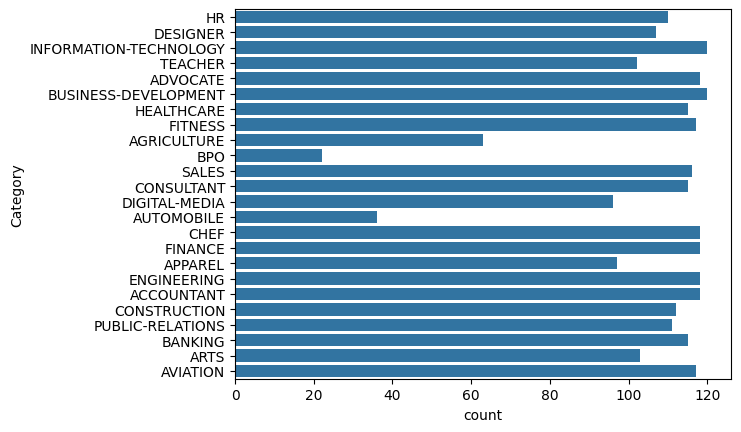

In [93]:
sns.countplot(df['Category'])

In [94]:
counts = df['Category'].value_counts()
labels = df['Category'].unique()

([<matplotlib.patches.Wedge at 0x2c81b9ae810>,
 [Text(1.0873558992701133, 0.16630438455579932, 'HR'),
  Text(0.9879404831198965, 0.4837081783604921, 'DESIGNER'),
  Text(0.8001110191456365, 0.7548657874362377, 'INFORMATION-TECHNOLOGY'),
  Text(0.5427553363733082, 0.9567740824449089, 'TEACHER'),
  Text(0.23740442402519826, 1.0740759467808894, 'ADVOCATE'),
  Text(-0.08893988823958886, 1.0963985116188044, 'BUSINESS-DEVELOPMENT'),
  Text(-0.40741934857491047, 1.021767818247764, 'HEALTHCARE'),
  Text(-0.6887870307285084, 0.857655190796514, 'FITNESS'),
  Text(-0.9089745936593924, 0.6194878433688129, 'AGRICULTURE'),
  Text(-1.0497142719294128, 0.32878556432377504, 'BPO'),
  Text(-1.0999287409107072, 0.01252057980233263, 'SALES'),
  Text(-1.057311143743458, -0.3034685244237055, 'CONSULTANT'),
  Text(-0.9258572387937805, -0.5939599088938216, 'DIGITAL-MEDIA'),
  Text(-0.7197731711526006, -0.8318212440716631, 'AUTOMOBILE'),
  Text(-0.45983075785550176, -0.9992775761168842, 'CHEF'),
  Text(-0.16630

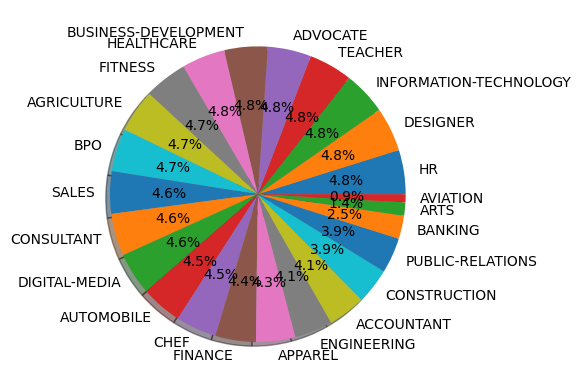

In [95]:
plt.pie(counts,labels = labels,autopct='%1.1f%%',shadow=True)

Cleaning Data

In [96]:
import re
def clean_resume(txt):
    clean_text = re.sub(r'http\S+\s*', ' ', txt)      
    clean_text = re.sub(r'\b(RT|cc)\b', ' ', clean_text)    
    clean_text = re.sub(r'#\S+', ' ', clean_text)       
    clean_text = re.sub(r'@\S+', ' ', clean_text)      
    clean_text = re.sub(r'[%s]' % re.escape(r"""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""),' ',clean_text)                                                  
    clean_text = re.sub(r'[^\x00-\x7f]', ' ', clean_text)  
    clean_text = re.sub(r'\s+', ' ', clean_text)

    return clean_text.strip()

In [97]:
text = "my #### #noorsaed website like is this http://helloWord and access it @gmail.com"

print(clean_resume(text))

my website like is this and access it


In [98]:
df['Resume_str'] = df['Resume_str'].apply(lambda x : clean_resume(x))

In [99]:
df['Resume_str'][0]

'HR ADMINISTRATOR MARKETING ASSOCIATE HR ADMINISTRATOR Summary Dedicated Customer Service Manager with 15 years of experience in Hospitality and Customer Service Management Respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service Highlights Focused on customer satisfaction Team management Marketing savvy Conflict resolution techniques Training and development Skilled multi tasker Client relations specialist Accomplishments Missouri DOT Supervisor Training Certification Certified by IHG in Customer Loyalty and Marketing by Segment Hilton Worldwide General Manager Training Certification Accomplished Trainer for cross server hospitality systems such as Hilton OnQ Micros Opera PMS Fidelio OPERA Reservation System ORS Holidex Completed courses and seminars in customer service sales strategies inventory control loss prevention safety time management leadership and performance assessment Experience HR Administrator Marketin

Words into categorical values

In [100]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [101]:
le.fit(df['Category'])
df['Category'] = le.transform(df['Category'])

In [102]:
df.Category.unique()

array([19, 13, 20, 23,  1,  9, 18, 17,  2,  8, 22, 12, 14,  5, 10, 16,  3,
       15,  0, 11, 21,  7,  4,  6])

Vectorization

In [103]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english',max_features=5000,ngram_range=(1,2))

tfidf.fit(df['Resume_str'])
required_text = tfidf.transform(df['Resume_str'])

Splitting

In [104]:
from sklearn.model_selection import train_test_split

In [105]:
x = required_text
y = df['Category']

In [106]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [107]:
x_train.shape

(1987, 5000)

In [108]:
x_test.shape

(497, 5000)

Training

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

lsvc = LinearSVC()

lsvc.fit(x_train, y_train)

c:\Users\Koshi Jain\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC()

In [111]:
y_pred_l = lsvc.predict(x_test)
accuracy_score(y_pred_l,y_test)

0.710261569416499

In [113]:
from sklearn.metrics import classification_report

print("SVM")
print(classification_report(
    y_test,
    y_pred_l,
    target_names=le.classes_
))

SVM
                        precision    recall  f1-score   support

            ACCOUNTANT       0.84      0.93      0.89        29
              ADVOCATE       0.58      0.70      0.64        30
           AGRICULTURE       0.33      0.25      0.29         8
               APPAREL       0.61      0.55      0.58        20
                  ARTS       0.45      0.28      0.34        18
            AUTOMOBILE       0.67      0.33      0.44         6
              AVIATION       0.86      0.86      0.86        21
               BANKING       0.75      0.65      0.70        23
                   BPO       0.00      0.00      0.00         2
  BUSINESS-DEVELOPMENT       0.95      0.74      0.83        27
                  CHEF       0.85      0.71      0.77        24
          CONSTRUCTION       0.88      0.85      0.87        34
            CONSULTANT       0.62      0.40      0.48        20
              DESIGNER       0.78      0.95      0.86        19
         DIGITAL-MEDIA       0.78  

In [ ]:
# import pickle
# pickle.dump(tfidf,open('tfidf.pkl','wb'))
# pickle.dump(lsvc,open('lsvc.pkl','wb'))


In [119]:
mapping = dict(enumerate(le.classes_))

In [120]:
mapping

{0: 'ACCOUNTANT',
 1: 'ADVOCATE',
 2: 'AGRICULTURE',
 3: 'APPAREL',
 4: 'ARTS',
 5: 'AUTOMOBILE',
 6: 'AVIATION',
 7: 'BANKING',
 8: 'BPO',
 9: 'BUSINESS-DEVELOPMENT',
 10: 'CHEF',
 11: 'CONSTRUCTION',
 12: 'CONSULTANT',
 13: 'DESIGNER',
 14: 'DIGITAL-MEDIA',
 15: 'ENGINEERING',
 16: 'FINANCE',
 17: 'FITNESS',
 18: 'HEALTHCARE',
 19: 'HR',
 20: 'INFORMATION-TECHNOLOGY',
 21: 'PUBLIC-RELATIONS',
 22: 'SALES',
 23: 'TEACHER'}